# Working with USB Hardware in v4.0

® *Copyright Bimea 2024-2026*

This notebook shows how v4.0 simplifies USB device management while still providing low-level access when needed.

Let's explore both the high-level (recommended) and low-level approaches.

In [ ]:
import numpy as np
import megamicros
from megamicros.log import log

# Set log level to INFO to see device detection details
log.setLevel("INFO")

print(f"Megamicros version: {megamicros.__version__}")

## Low-Level USB Access (Advanced)

For advanced users who need direct control over USB transfers, the low-level `Usb` class is available.

**⚠ Warning**: Only use this if configure custom USB behaviors. Most users should use the high-level API above.

In what follows you can check your hardware megamicros device. 

In [ ]:
from megamicros.usb import Usb

# Megamicros USB device identifiers
VENDOR_ID = 0xFE27
PRODUCT_IDS = {
    0xAC00: "Mu32-usb2",
    0xAC01: "Mu256-usb3",
    0xAC02: "Mu1024-usb3",
    0xAC03: "Mu32-usb3",
    0xAC04: "Mu64-usb3"
}

# Check for any Megamicros device
device_found = False
detected_product_ids = []

for product_id, device_name in PRODUCT_IDS.items():
    if Usb.checkDeviceByVendorProduct(vendor_id=VENDOR_ID, product_id=product_id):
        print(f"✓ Found: {device_name} (Product ID: 0x{product_id:04X})")
        device_found = True
        detected_product_ids.append(product_id)

if not device_found:
    print("⚠ No Megamicros USB device found")
    print("Available product IDs:", [f"0x{pid:04X}" for pid in PRODUCT_IDS.keys()])

### Low-Level USB Operations

If you found a device above, you can perform low-level operations:

In [ ]:
if device_found:
    detected_product_id=detected_product_ids[0]  # Use the first detected device for demonstration
    try:
        # Initialize USB connection
        usb_device = Usb()
        usb_device.open(
            vendor_id=VENDOR_ID,
            product_id=detected_product_id,
            bus_address=0x00,
            endpoint_in=0x81
        )
        
        # Claim interface for exclusive access
        usb_device.claim()
        
        print("✓ USB device opened and claimed")
        print(f"  Endpoint IN: 0x81")
        print(f"  Transfer buffer size: {usb_device.buffer_size} bytes")
        
        # Release interface when done
        usb_device.release()
        usb_device.close()
        
        print("✓ USB device released and closed")
        
    except Exception as e:
        print(f"⚠ Low-level USB error: {e}")
else:
    print("⚠ Skipping low-level operations (no device found)")

## USB data source Interface

The UsbDataSource interfaces with physical Megamicros USB devices (Mu364-128, Mu256, Mu1024) for real-time data acquisition from MEMS microphone arrays.
This is the low level library access to megamicros devices.

Features are:
- Direct USB communication with hardware
- Multi-threaded asynchronous transfers
- Thread-safe queue management
- FPGA command interface
- Support for int32 and float32 datatypes

Let's try with a Mµ32 device.

In [1]:
from megamicros.log import log
from megamicros.sources import UsbDataSource
from megamicros.core.config import AcquisitionConfig, UsbConfig

# Set log level to INFO to see device detection details
log.setLevel("INFO")

PRODUCT_ID = 0xAC03  # Example: Mu32-usb3

try:
    # Configure for a specific device (e.g., Mu32)
    usb_config = UsbConfig(vendor_id=0xFE27, product_id=PRODUCT_ID)
    source = UsbDataSource(usb_config)

    # Configure a basic acquisition (e.g., 1024 samples per frame, all available MEMS)
    acquisition_config = AcquisitionConfig(
        mems=[0, 1, 2, 3],
        frame_length=1024,
        duration = 1
    )

    source.configure(acquisition_config)

    print(f"Source configured: {source.info}")
except Exception as e:
    print(f"⚠ Error during configuration: {e}")


2026-04-04 01:06:44,879 [INFO]: UsbDataSource initialized: 32 MEMS available
2026-04-04 01:06:44,879 [INFO]:  .Connecting to USB device fe27:ac03 ...
2026-04-04 01:06:44,886 [INFO]:  .Connected on USB device fe27:ac03
2026-04-04 01:06:44,887 [INFO]: USB configured: 20480 bytes/frame, 5 channels, 8 buffers
2026-04-04 01:06:44,889 [INFO]: RESET and PURGE commands sent to FPGA
2026-04-04 01:06:44,890 [INFO]: Sampling frequency 44100Hz sent as clockdiv 10 (nearest activated frequency is 45454Hz)
2026-04-04 01:06:44,892 [INFO]: Active channels sent to FPGA: MEMS=4, Analogs=0, Counter=1, Status=False
2026-04-04 01:06:44,894 [INFO]: Datatype sent to FPGA: int32
2026-04-04 01:06:44,895 [INFO]: Sample count sent to FPGA: 0 (streaming mode if 0)


Source configured: MemsArrayInfo(description='USB Device 0xfe27:0xac03', available_mems=[0, ...] (32 total))


Remember that the lifecycle is: 

    IDLE → configure() → CONFIGURED → start() → RUNNING → stop() → STOPPED.

For example you cannot configure de device two consecutive times, nor can you start it without configuring it first.
Also a good way to do is to wrap your code in a try-except block.
If you encounter any issues, please restart the kernel and set the logging level to `DEBUG` to see what's happening.

Now that the device is configured, let's start an acquisition:

In [2]:
try:       
    source.start()
    source.wait()
    source.stop()
except Exception as e:
    print(f"⚠ Error during acquisition: {e}")

2026-04-04 01:07:18,051 [INFO]: START command sent to FPGA
2026-04-04 01:07:18,052 [INFO]: Starting native USB async bulk transfer (duration=1s, expected frames=44)
2026-04-04 01:07:18,053 [INFO]:  .Init asynchronous bulk transfer...
2026-04-04 01:07:18,054 [INFO]:  .Transfer thread execution started
2026-04-04 01:07:19,059 [INFO]:  .Thread timer ended: stop the bulk transfer...
2026-04-04 01:07:19,063 [INFO]: STOP command sent to FPGA
2026-04-04 01:07:20,177 [INFO]:  .Quitting transfer loop due to end of process request...


How many frames have been acquired ? 

In [3]:
print(f"{source.queue_content} frames acquired")
print(f"{source.transfert_lost} frames lost")

44 frames acquired
0 frames lost


You can get frames by iterate on them:

In [4]:
for i, frame in  enumerate(source):
    print(f"Frame {i}: shape={frame.shape}, dtype={frame.dtype}")

Frame 0: shape=(5, 1024), dtype=int32
Frame 1: shape=(5, 1024), dtype=int32
Frame 2: shape=(5, 1024), dtype=int32
Frame 3: shape=(5, 1024), dtype=int32
Frame 4: shape=(5, 1024), dtype=int32
Frame 5: shape=(5, 1024), dtype=int32
Frame 6: shape=(5, 1024), dtype=int32
Frame 7: shape=(5, 1024), dtype=int32
Frame 8: shape=(5, 1024), dtype=int32
Frame 9: shape=(5, 1024), dtype=int32
Frame 10: shape=(5, 1024), dtype=int32
Frame 11: shape=(5, 1024), dtype=int32
Frame 12: shape=(5, 1024), dtype=int32
Frame 13: shape=(5, 1024), dtype=int32
Frame 14: shape=(5, 1024), dtype=int32
Frame 15: shape=(5, 1024), dtype=int32
Frame 16: shape=(5, 1024), dtype=int32
Frame 17: shape=(5, 1024), dtype=int32
Frame 18: shape=(5, 1024), dtype=int32
Frame 19: shape=(5, 1024), dtype=int32
Frame 20: shape=(5, 1024), dtype=int32
Frame 21: shape=(5, 1024), dtype=int32
Frame 22: shape=(5, 1024), dtype=int32
Frame 23: shape=(5, 1024), dtype=int32
Frame 24: shape=(5, 1024), dtype=int32
Frame 25: shape=(5, 1024), dtype=in

One can do the same in real time by iterating during the acquisition process:

In [5]:
log.setLevel("INFO")

try:       
    # Configure the source again to reset internal state and counters
    source.configure(acquisition_config)
    source.start()
            
    for frame in source:
        print(f"Frame: {frame.shape}")

    source.wait()
    source.stop()
except Exception as e:
    print(f"⚠ Error during acquisition: {e}")

print(f"{source.queue_content} frames acquired")
print(f"{source.transfert_lost} frames lost")

2026-04-04 01:09:30,430 [INFO]: USB configured: 20480 bytes/frame, 5 channels, 8 buffers
2026-04-04 01:09:30,434 [INFO]: RESET and PURGE commands sent to FPGA
2026-04-04 01:09:30,436 [INFO]: Sampling frequency 44100Hz sent as clockdiv 10 (nearest activated frequency is 45454Hz)
2026-04-04 01:09:30,439 [INFO]: Active channels sent to FPGA: MEMS=4, Analogs=0, Counter=1, Status=False
2026-04-04 01:09:30,440 [INFO]: Datatype sent to FPGA: int32
2026-04-04 01:09:30,441 [INFO]: Sample count sent to FPGA: 0 (streaming mode if 0)
2026-04-04 01:09:30,443 [INFO]: START command sent to FPGA
2026-04-04 01:09:30,444 [INFO]: Starting native USB async bulk transfer (duration=1s, expected frames=44)
2026-04-04 01:09:30,444 [INFO]:  .Init asynchronous bulk transfer...
2026-04-04 01:09:30,445 [INFO]:  .Transfer thread execution started


Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)


2026-04-04 01:09:31,450 [INFO]:  .Thread timer ended: stop the bulk transfer...
2026-04-04 01:09:31,452 [INFO]: STOP command sent to FPGA


Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)
Frame: (5, 1024)


2026-04-04 01:09:32,544 [INFO]:  .Quitting transfer loop due to end of process request...


0 frames acquired
0 frames lost


Here we also **concatenate frames** to get the complete signal.

**Key concept**: Each frame has shape `(channels, samples_per_frame)`. To reconstruct the complete signal, use `np.concatenate(frames, axis=1)` to concatenate along the samples axis, giving you shape `(channels, total_samples)`.

**Warning**: 
- `axis=1` concatenates along samples (→ continuous signal)
- `axis=0` would stack channels (incorrect for signal reconstruction)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
log.setLevel("INFO")

frames = []
try:       
    source.configure(acquisition_config)
    source.start()
            
    # Collect frames in a list
    for frame in source:
        frames.append(frame)

    source.wait()
    source.stop()
except Exception as e:
    print(f"⚠ Error during acquisition: {e}")

signal = np.concatenate(frames, axis=1)
print(f"data shape: {signal.shape}")

# If counter is True, channel 0 is the counter
mems_offset = 1 if acquisition_config.counter else 0

# Individual access
mems_0 = signal[mems_offset, :]      # First MEMS
mems_1 = signal[mems_offset+1, :]    # Second MEMS

# All MEMS (without counter)
all_mems = signal[mems_offset:, :]

2026-04-04 01:09:37,780 [INFO]: USB configured: 20480 bytes/frame, 5 channels, 8 buffers
2026-04-04 01:09:37,784 [INFO]: RESET and PURGE commands sent to FPGA
2026-04-04 01:09:37,785 [INFO]: Sampling frequency 44100Hz sent as clockdiv 10 (nearest activated frequency is 45454Hz)
2026-04-04 01:09:37,787 [INFO]: Active channels sent to FPGA: MEMS=4, Analogs=0, Counter=1, Status=False
2026-04-04 01:09:37,789 [INFO]: Datatype sent to FPGA: int32
2026-04-04 01:09:37,790 [INFO]: Sample count sent to FPGA: 0 (streaming mode if 0)
2026-04-04 01:09:37,791 [INFO]: START command sent to FPGA
2026-04-04 01:09:37,791 [INFO]: Starting native USB async bulk transfer (duration=1s, expected frames=44)
2026-04-04 01:09:37,791 [INFO]:  .Init asynchronous bulk transfer...
2026-04-04 01:09:37,792 [INFO]:  .Transfer thread execution started
2026-04-04 01:09:38,797 [INFO]:  .Thread timer ended: stop the bulk transfer...
2026-04-04 01:09:38,800 [INFO]: STOP command sent to FPGA
2026-04-04 01:09:39,834 [INFO]: 

data shape: (5, 45056)


Now you can plot some MEMS signals

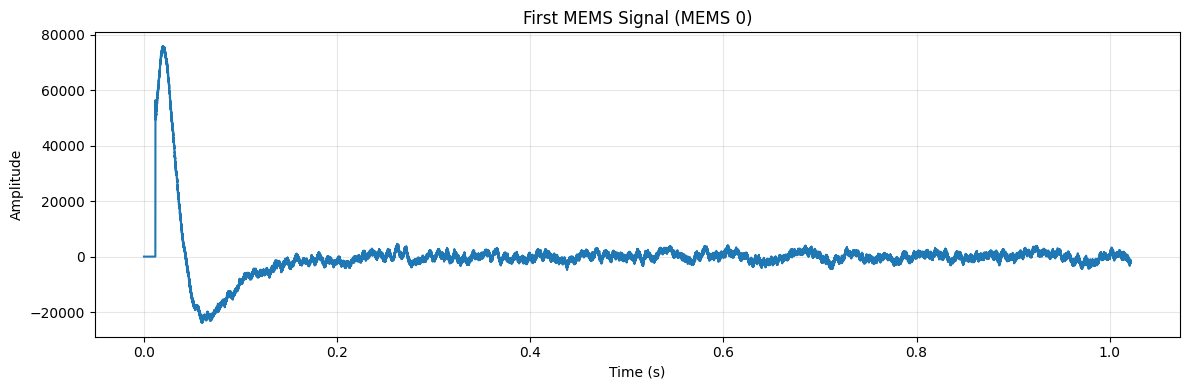

In [7]:
import matplotlib.pyplot as plt

# Create time axis (in seconds)
time = np.arange(signal.shape[1]) / acquisition_config.sampling_frequency

# Plot first MEMS signal
plt.figure(figsize=(12, 4))
plt.plot(time, mems_0)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('First MEMS Signal (MEMS 0)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

See the counter values to check if no data have been lost. You should see an upward-sloping line.

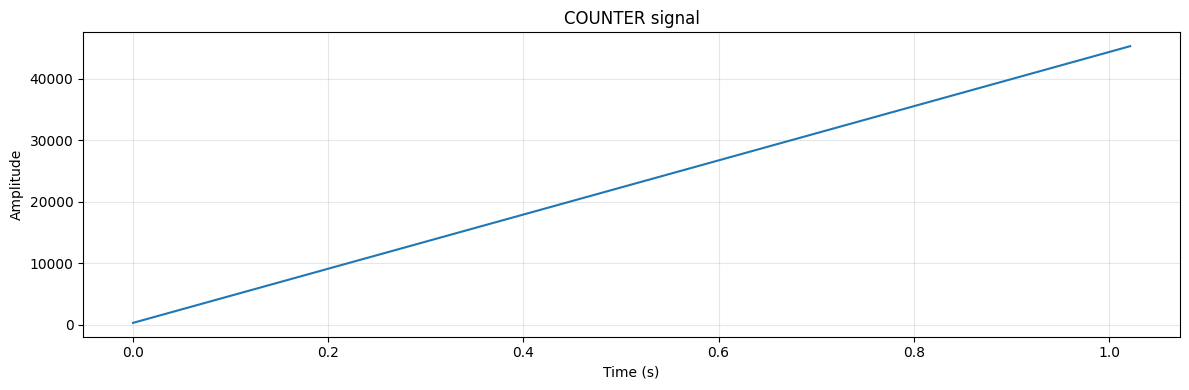

In [8]:
counter = signal[0, :]

# Plot counter signal
plt.figure(figsize=(12, 4))
plt.plot(time, counter)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('COUNTER signal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Transient Analysis

With `time_activation=0`, you'll see a **transient state** in the first ~200ms:
- MEMS are powering up
- ADC values stabilize
- Counter may have lower initial values

**Recommendation**: Use default `time_activation=200` (ms) for USB hardware unless you need ultra-fast startup:

2026-04-04 01:09:55,217 [INFO]: USB configured: 20480 bytes/frame, 5 channels, 8 buffers
2026-04-04 01:09:55,221 [INFO]: RESET and PURGE commands sent to FPGA
2026-04-04 01:09:55,223 [INFO]: Sampling frequency 44100Hz sent as clockdiv 10 (nearest activated frequency is 45454Hz)
2026-04-04 01:09:55,225 [INFO]: Active channels sent to FPGA: MEMS=4, Analogs=0, Counter=1, Status=False
2026-04-04 01:09:55,227 [INFO]: Datatype sent to FPGA: int32
2026-04-04 01:09:55,228 [INFO]: Sample count sent to FPGA: 0 (streaming mode if 0)
2026-04-04 01:09:55,435 [INFO]: START command sent to FPGA
2026-04-04 01:09:55,436 [INFO]: Starting native USB async bulk transfer (duration=1s, expected frames=44)
2026-04-04 01:09:55,436 [INFO]:  .Init asynchronous bulk transfer...
2026-04-04 01:09:55,437 [INFO]:  .Transfer thread execution started
2026-04-04 01:09:56,442 [INFO]:  .Thread timer ended: stop the bulk transfer...
2026-04-04 01:09:56,444 [INFO]: STOP command sent to FPGA
2026-04-04 01:09:57,559 [INFO]: 

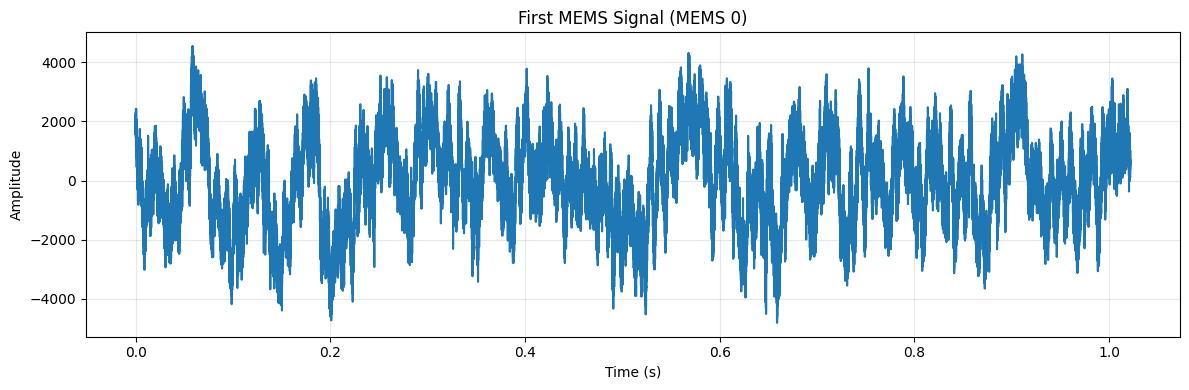

In [ ]:
log.setLevel("INFO")

frames = []
acquisition_config.time_activation=200
try:       
    source.configure(acquisition_config)
    source.start()
            
    # Collect frames in a list
    for frame in source:
        frames.append(frame)

    source.wait()
    source.stop()
except Exception as e:
    print(f"⚠ Error during acquisition: {e}")

signal = np.concatenate(frames, axis=1)
counter = signal[0, :]                  # Counter
mems_0 = signal[mems_offset, :]         # First MEMS

# Create time axis (in seconds)
time = np.arange(signal.shape[1]) / acquisition_config.sampling_frequency

# Plot first MEMS signal
plt.figure(figsize=(12, 4))
plt.plot(time, mems_0)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('First MEMS Signal (MEMS 0)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


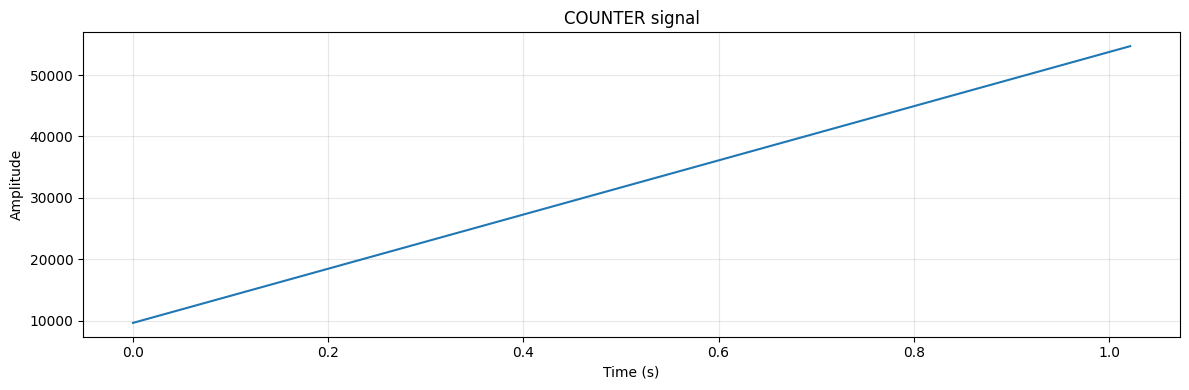

In [10]:
counter = signal[0, :]

# Plot counter signal
plt.figure(figsize=(12, 4))
plt.plot(time, counter)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('COUNTER signal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Data Type Conversion: int32 vs float32

**int32**: Raw ADC values (24-bit signed, stored as int32)  
**float32**: Automatically converted to **Pascals** using MEMS sensibility

**Default sensibility**: `3.54e-6 Pa/digit` (can be calibrated per-antenna)

In [11]:
# Acquire same signal in both formats
configs = [
    AcquisitionConfig(mems=[0], duration=1, frame_length=1024, datatype='int32'),
    AcquisitionConfig(mems=[0], duration=1, frame_length=1024, datatype='float32')
]

results = {}

try: 
    for cfg in configs:
        frames = []
        source.configure(cfg)
        source.start()
                
        # Collect frames in a list
        for frame in source:
            frames.append(frame)

        source.wait()
        source.stop()

        signal = np.concatenate(frames, axis=1)[1, :]  # First MEMS (assuming counter is at index 0)
        results[cfg.datatype] = signal

except Exception as e:
    print(f"⚠ Error during acquisition: {e}")

# Compare
print("Data Type Comparison:")
print(f"int32 range: {results['int32'].min()} to {results['int32'].max()}")
print(f"int32 dtype: {results['int32'].dtype}")
print(f"\nfloat32 range: {results['float32'].min():.2e} to {results['float32'].max():.2e} Pa")
print(f"float32 dtype: {results['float32'].dtype}")
# print(f"\nConversion factor: {antenna.mems_sensibility:.2e} Pa/digit")

2026-04-04 01:19:12,546 [INFO]: USB configured: 8192 bytes/frame, 2 channels, 8 buffers
2026-04-04 01:19:12,550 [INFO]: RESET and PURGE commands sent to FPGA
2026-04-04 01:19:12,551 [INFO]: Sampling frequency 44100Hz sent as clockdiv 10 (nearest activated frequency is 45454Hz)
2026-04-04 01:19:12,554 [INFO]: Active channels sent to FPGA: MEMS=1, Analogs=0, Counter=1, Status=False
2026-04-04 01:19:12,555 [INFO]: Datatype sent to FPGA: int32
2026-04-04 01:19:12,557 [INFO]: Sample count sent to FPGA: 0 (streaming mode if 0)
2026-04-04 01:19:12,558 [INFO]: START command sent to FPGA
2026-04-04 01:19:12,559 [INFO]: Starting native USB async bulk transfer (duration=1s, expected frames=44)
2026-04-04 01:19:12,559 [INFO]:  .Init asynchronous bulk transfer...
2026-04-04 01:19:12,561 [INFO]:  .Transfer thread execution started
2026-04-04 01:19:13,566 [INFO]:  .Thread timer ended: stop the bulk transfer...
2026-04-04 01:19:13,568 [INFO]: STOP command sent to FPGA
2026-04-04 01:19:14,661 [INFO]:  

Data Type Comparison:
int32 range: -22914 to 77106
int32 dtype: int32

float32 range: -3.77e+03 to 4.25e+03 Pa
float32 dtype: float32


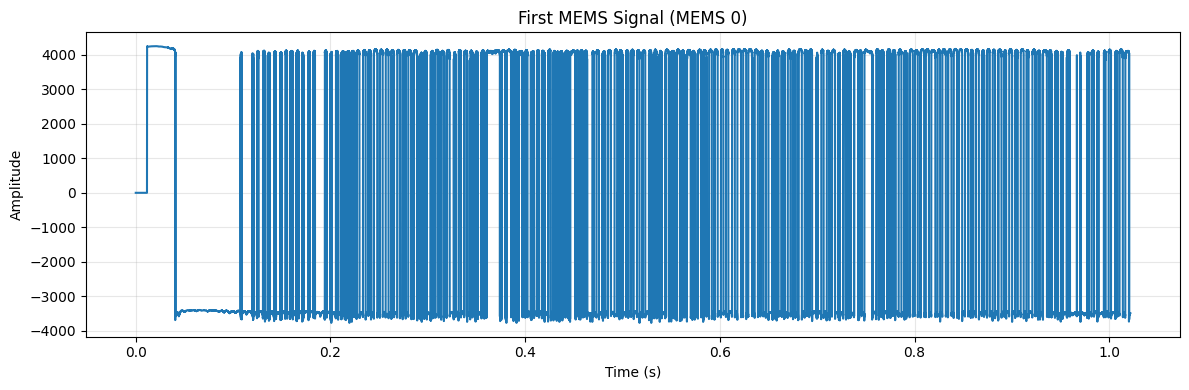

In [15]:
# Plot MEMS signal
mems_0 = results['float32']  # Using float32 for plotting

# Create time axis (in seconds)
time = np.arange(mems_0.shape[0]) / acquisition_config.sampling_frequency

plt.figure(figsize=(12, 4))
plt.plot(time, mems_0)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('First MEMS Signal (MEMS 0)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

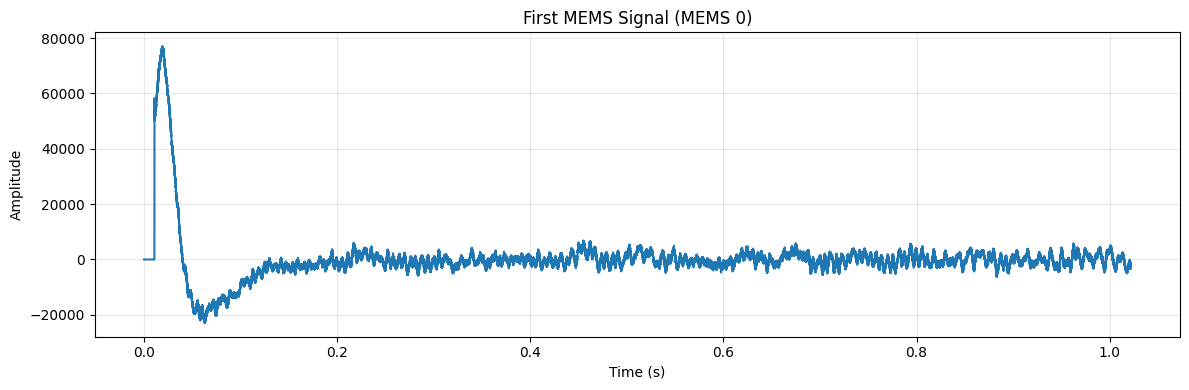

In [16]:
# Plot MEMS signal
mems_0 = results['int32']  # Using float32 for plotting

# Create time axis (in seconds)
time = np.arange(mems_0.shape[0]) / acquisition_config.sampling_frequency

plt.figure(figsize=(12, 4))
plt.plot(time, mems_0)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('First MEMS Signal (MEMS 0)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Troubleshooting USB Connections

### Linux
In some Linux distributions, only the root user has access to the USB port, so the following message may appear:

```bash
    ...
    aborting:  LIBUSB_ERROR_ACCESS [-3]
```

```bash
sudo tee /etc/udev/rules.d/99-megamicros-devices.rules > /dev/null << 'EOF'
# Megamicros devices
SUBSYSTEM=="usb", ATTR{idVendor}=="fe27", ATTR{idProduct}=="ac00", MODE="0666"
SUBSYSTEM=="usb", ATTR{idVendor}=="fe27", ATTR{idProduct}=="ac01", MODE="0666"
SUBSYSTEM=="usb", ATTR{idVendor}=="fe27", ATTR{idProduct}=="ac02", MODE="0666"
SUBSYSTEM=="usb", ATTR{idVendor}=="fe27", ATTR{idProduct}=="ac03", MODE="0666"
SUBSYSTEM=="usb", ATTR{idVendor}=="fe27", ATTR{idProduct}=="ac04", MODE="0666"
EOF

sudo udevadm control --reload-rules
sudo udevadm trigger
```

User should be also in the ``plugdev`` group. Check the group file:

```bash
    > vi /etc/group
    ...
    plugdev:x:46:user_account_login
    ...
```

If there is no entry with your user account (``user_account_login`` above), then add your user account in the ``plugdev`` group.
Unplugg and plugg your usb device. All should be fine.

Don't forget that if you run your Python programs on a virtual machine, usb ports should be declared as accessible on your VM.

### macOS
Ensure you have the correct permissions:

```bash
# Check if device is visible
system_profiler SPUSBDataType | grep -i megamicros

# If not visible, try unplugging and replugging the device
```

### Windows
Before using the megamicros python library you must install the *Zadig* usb driver. 

### Device Already in Use
If another process is using the device:

```python
from megamicros.exception import MuException

try:
    antenna = Megamicros(usb=True)
except MuException as e:
    print(f"Error: {e}")
    print("Try closing other applications using the device")
```

import numpy as np
log.setLevel("INFO")

# Collect frames in a list
frames = []
try:       
    source.configure(acquisition_config)
    source.start()
            
    for frame in source:
        frames.append(frame)

    source.wait()
    source.stop()
except Exception as e:
    print(f"⚠ Error during acquisition: {e}")

# Concatenate all frames along the samples axis (axis=1)
if frames:
    signal = np.concatenate(frames, axis=1)
    print(f"Complete signal shape: {signal.shape}")





    print("No frames collected")else:    print(f"  - Duration: {signal.shape[1] / acquisition_config.sampling_frequency:.3f} seconds")    print(f"  - Total samples: {signal.shape[1]}")    print(f"  - Channels: {signal.shape[0]}")    print(f"  - Channels: {signal.shape[0]}")
    print(f"  - Total samples: {signal.shape[1]}")
    print(f"  - Duration: {signal.shape[1] / acquisition_config.sampling_frequency:.3f} seconds")
else:
    print("No frames collected")





    print("No frames collected")else:    print(f"  - Duration: {signal.shape[1] / acquisition_config.sampling_frequency:.3f} seconds")    print(f"  - Total samples: {signal.shape[1]}")    print(f"  - Channels: {signal.shape[0]}")    print(f"Complete signal shape: {signal.shape}")    signal = np.concatenate(frames, axis=1)    signal = np.concatenate(frames, axis=1)
    print(f"Complete signal shape: {signal.shape}")
    print(f"  - Channels: {signal.shape[0]}")
    print(f"  - Total samples: {signal.shape[1]}")
    print(f"  - Duration: {signal.shape[1] / acquisition_config.sampling_frequency:.3f} seconds")
else:
    print("No frames collected")